# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

In [53]:
'''
Project: Financial Crime and Fraud Detection

Dataset: European Credit Card Fraud Detection Dataset

Who: Looking at talking to banks

What: which accounts to flag to catch fraud

How: look at time and amount to see if it produced fraud
'''


'\nProject: Financial Crime and Fraud Detection\n\nDataset: European Credit Card Fraud Detection Dataset\n\nWho: Looking at talking to banks\n\nWhat: which accounts to flag to catch fraud\n\nHow: look at time and amount to see if it produced fraud\n'

# 3. Homework - work with your own data

In [54]:
import pandas as pd
import numpy as np
import kagglehub
import os
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [55]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)
csv_file = os.path.join(path, "creditcard.csv")

df_fraud = pd.read_csv(csv_file)

Path to dataset files: C:\Users\alh55\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [56]:
df_fraud.info()
df_fraud.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [57]:
non_PCA = ['Time', 'Amount', 'Class']
df_fraud[non_PCA].head()

,Time,Amount,Class
0,0.0,149.62,0
1,0.0,2.69,0
2,1.0,378.66,0
3,1.0,123.50,0
4,2.0,69.99,0


In [58]:
# duplicate

num_dupes = df_fraud[df_fraud.duplicated()]
print(f'Number of duplicates: {len(num_dupes)}')

Number of duplicates: 1081


In [59]:
print('Column     Mean         Median         Mode')
print('-------   ----------    ----------   -------')
for c in df_fraud.columns:
    print(f'{c:<5}    {df_fraud[c].mean():<.5}   {df_fraud[c].median():<.5}   {df_fraud[c].mode()[0]}')

Column     Mean         Median         Mode
-------   ----------    ----------   -------
Time     9.4814e+04   8.4692e+04   163152.0
V1       1.1752e-15   0.018109   1.24567381944824
V2       3.385e-16   0.065486   -0.32666777306077
V3       -1.3795e-15   0.17985   -2.75204095570008
V4       2.0949e-15   -0.019847   -0.842316033286871
V5       1.0219e-15   -0.054336   -0.562776680773863
V6       1.4945e-15   -0.27419   -1.01107261632698
V7       -5.6203e-16   0.040103   -0.432125923987824
V8       1.1496e-16   0.022358   -0.160210863301812
V9       -2.4142e-15   -0.051429   0.17036185217373
V10      2.2386e-15   -0.092917   -0.0751861699398929
V11      1.7244e-15   -0.032757   -0.35674901847752
V12      -1.2454e-15   0.14003   -0.0734595173503765
V13      8.2389e-16   -0.013568   -0.517759694198053
V14      1.2135e-15   0.050601   0.406968934383731
V15      4.8667e-15   0.048072   1.12414692288685
V16      1.4362e-15   0.066413   -0.371962125028419
V17      -3.7682e-16   -0.065676   -0

In [60]:
'''
There are no null or missing values or categorical. 
Column V1-V28 are PCA so hard to understand but other columns are numerical and straight forward
'''

'\nThere are no null or missing values or categorical. \nColumn V1-V28 are PCA so hard to understand but other columns are numerical and straight forward\n'

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

C:\Users\alh55\AppData\Local\Temp\ipykernel_8404\1871158131.py:6: RuntimeWarning: divide by zero encountered in divide
  y = (10/(X+1))
C:\Users\alh55\AppData\Local\Temp\ipykernel_8404\1871158131.py:7: RuntimeWarning: invalid value encountered in sqrt
  y2 = numpy.sqrt(X) + 0.5*X


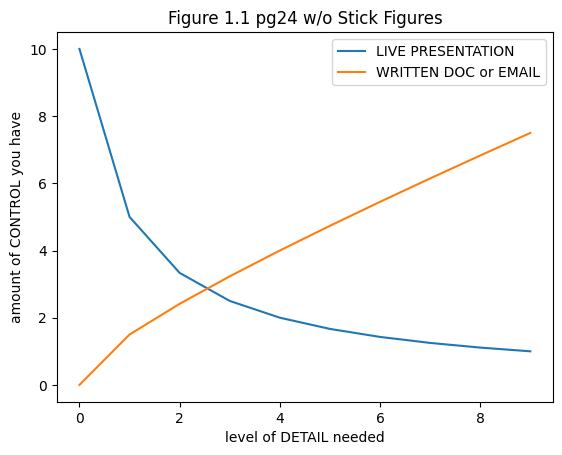

In [61]:
import matplotlib.pyplot as plt
import numpy
import math

X = np.arange(-1,10)
y = (10/(X+1))
y2 = numpy.sqrt(X) + 0.5*X

plt.plot(X,y,label="LIVE PRESENTATION")
plt.plot(X,y2,label="WRITTEN DOC or EMAIL")

plt.xlabel("level of DETAIL needed")
plt.ylabel("amount of CONTROL you have")
plt.title("Figure 1.1 pg24 w/o Stick Figures")
plt.legend()
plt.show()

In [62]:
'''
To get this graph I googled types of functions graphed to remember how some looked that would mimic the image 
then played around with some constants to get better shapes
'''

'\nTo get this graph I googled types of functions graphed to remember how some looked that would mimic the image \nthen played around with some constants to get better shapes\n'